In [2]:
from google.colab import files
uploaded = files.upload()

Saving resume_dataset.csv.xlsx to resume_dataset.csv.xlsx


Resume Ranking:
   Resume_ID  Match_Score
0          1     0.790619
6          7     0.471833
4          5     0.405676
2          3     0.249390
3          4     0.000000
1          2     0.000000
5          6     0.000000
7          8     0.000000


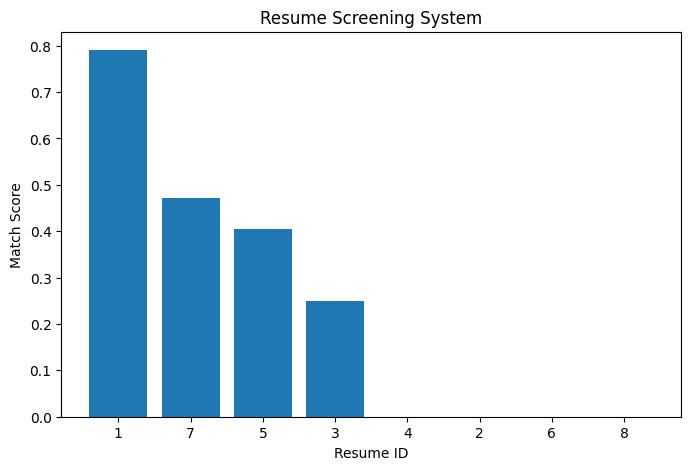

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load Resume Dataset
df = pd.read_excel("resume_dataset.csv.xlsx")

# Job Description
job_description = """
Python Developer with Machine Learning,
SQL, Data Analysis and NLP skills
"""

# Resume Text
resumes = df["Resume"]

# Combine JD and Resumes
documents = [job_description] + resumes.tolist()

# Convert text to numbers
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(documents)

# Calculate Similarity
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

# Create Ranking Table
results = pd.DataFrame({
    "Resume_ID": range(1, len(resumes)+1),
    "Match_Score": similarity_scores[0]
})

# Sort by highest score
results = results.sort_values(
    by="Match_Score",
    ascending=False
)

print("Resume Ranking:")
print(results)

# Graph
plt.figure(figsize=(8,5))

plt.bar(
    results["Resume_ID"].astype(str),
    results["Match_Score"]
)

plt.xlabel("Resume ID")
plt.ylabel("Match Score")
plt.title("Resume Screening System")

plt.savefig("resume_ranking.png")

plt.show()

In [11]:
import os

os.makedirs("FUTURE_ML_03/data", exist_ok=True)
os.makedirs("FUTURE_ML_03/images", exist_ok=True)
os.makedirs("FUTURE_ML_03/notebooks", exist_ok=True)

print("Folders Created Successfully")
import shutil

shutil.copy(
    "resume_dataset.csv.xlsx",
    "FUTURE_ML_03/data/resume_dataset.csv.xlsx"
)
plt.savefig("resume_ranking.png")
plt.savefig("FUTURE_ML_03/images/resume_ranking.png")

Folders Created Successfully


<Figure size 640x480 with 0 Axes>